# Hindlimb Model Edits 
+ Use this notebook to keep track of code used to edit the hindlimb model
+ Place functions in the `src` directory and import them in the blocks that need them 
+ Document your changes with markdown cells before the code block in the style of:

## Step 0: Load the model
This step loads the model and sets up the environment for editing.

In [5]:
import pyopensim as osim

# Load the model
graph = osim.Model('models/osim/rat_hindlimb.osim')

[info] Updating Model file from 40000 to latest format...
[info] Loaded model RatHindlimbRight from file models/osim/rat_hindlimb.osim
[warning] Couldn't find file 'ground.vtp'.
[warning] Couldn't find file 'spine.vtp'.
[warning] Couldn't find file 'pelvis.vtp'.
[warning] Couldn't find file 'femur.vtp'.
[warning] Couldn't find file 'tibia.vtp'.
[warning] Couldn't find file 'foot.vtp'.


## Step 1: Convert Thelen muscles to Millard
There is an error in the equilibrate muscles function for Thelen muscles, and Millard muscles are more prevalent.

In [ ]:
from src.rathindlimb import model_thelen_to_millard

millard_model = model_thelen_to_millard(graph)
# Save the modified model
millard_model.printToXML('models/osim/rat_hindlimb_millard.osim')


True

## Step 2: Analyze muscle lengths and moment arms
Create plots of the muscle lengths and moment arms to find discontinuities or other potential errors.

In [7]:
from movedb.osim import OsimGraph

millard_tsl_model = millard_model.clone()
graph = OsimGraph(osim_model=millard_tsl_model)

# Iterate through the range of motion to compute lengths and moment arms for all muscles
results = graph.get_all_muscle_lengths_rom(min_points=10000)

2025-11-19 04:15:18.586 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_pitch range: (-1.57079633, 1.57079633)
2025-11-19 04:15:18.587 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_roll range: (-1.57079633, 1.57079633)
2025-11-19 04:15:18.587 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_yaw range: (-1.57079633, 1.57079633)
2025-11-19 04:15:18.587 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_x range: (-0.1, 0.25)
2025-11-19 04:15:18.588 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_y range: (0.0, 0.2)
2025-11-19 04:15:18.588 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_z range: (-0.1, 0.1)
2025-11-19 04:15:18.592 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:146 - Joint ground_spine connects ground and spine
2025-11-19 0

[info] 'BFa' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'BFp' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'CF' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'STp' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'STa' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'SM' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'QF' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'TFL' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'GMa' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 bu

In [10]:
import plotly.graph_objects as go
import os
# import plotly.io as pio
# pio.renderers.default = "notebook"
figure_dir = 'figs'

# Plot lengths and moment arms to identify problems
for muscle_name, muscle_data in results.items():
    # Plot parallel coordinates of muscle lengths
    fig1 = go.Figure(data=
        go.Parcoords(
            line=dict(color=muscle_data[muscle_name], colorscale='Viridis', showscale=True),
            dimensions=[dict(
                label=col,
                values=muscle_data[col],
            )
            for col in muscle_data.columns if not 'moment_arm' in col]
        )   
    )   
    fig1.update_layout(title=muscle_name + ' Lengths')
    # fig1.write_html(f"{figure_dir}/{muscle_name}_length.html")
    if not os.path.exists(f"{figure_dir}/{muscle_name}"):
        os.makedirs(f"{figure_dir}/{muscle_name}")
    fig1.write_image(f"{figure_dir}/{muscle_name}/{muscle_name}_length.png")

    moment_arm_cols = [col for col in muscle_data.columns if 'moment_arm' in col]
    coord_cols = [col for col in muscle_data.columns if not 'moment_arm' in col and col != 'length']
    for moment_arm in moment_arm_cols:
        # Plot scatter plot of moment arm versus singular coordinate
        for coord in coord_cols:
            fig2 = go.Figure(data=
                go.Scatter(
                    x=muscle_data[coord],
                    y=muscle_data[moment_arm],
                    mode='markers',
                    marker=dict(color=muscle_data[moment_arm], colorscale='Viridis', showscale=True),
                )
            )
            fig2.update_layout(title=f'{muscle_name} {moment_arm} vs {coord}')
            # fig2.write_html(f"{figure_dir}/{muscle_name}_{moment_arm}_vs_{coord}.html")
            fig2.write_image(f"{figure_dir}/{muscle_name}/{muscle_name}_{moment_arm}_vs_{coord}.png")

### Potentially problematic muscles
#### BFa 
![BFa Length](./figs/BFa/BFa_length.png)

#### CF
![CF Length](./figs/CF/CF_length.png)

#### STp
![STp Length](./figs/STp/STp_length.png)

#### TA
![TA Length](./figs/TA/TA_length.png)

#### VL
![VL Length](./figs/VL/VL_length.png)

Because of the hard-coded value in [OpenSim's WrapCylinder.cpp code](https://github.com/opensim-org/opensim-core/blob/f9cd558ec3ea99dda206e5e412e62e23cf19bd7e/OpenSim/Simulation/Wrap/WrapCylinder.cpp#L668):

```c++
// Each muscle segment on the surface of the cylinder should be
// 0.002 meters long. This assumes the model is in meters, of course.
int numWrapSegments = (int)(aWrapResult.wrap_path_length / 0.002);
if (numWrapSegments < 1) numWrapSegments = 1;
```
we need to modify the wrapping surfaces to prevent discontinuities in muscle lengths that appear in the range of motion of the rats during normal gait

## Step 3: Modify muscle paths
We plan to use the attachment points presented in Young's work which builds upon Johnson and Greene's original anatomical text. However, the coordinate systems are defined differently and the scale is different. We will need to adjust the values accordingly. To achieve this, we will calculate the necessary transformation matrices and apply them to the data points.

This can be done by determining the homogenous transformation matrices for each body coordinate system and transforming the values from Young's coordinate system to Johnson model's coordinate system. The transformation matrices will be derived based on the anatomical landmarks defined in both coordinate systems, ensuring accurate mapping of the data points. 

One method to achieve this is to use mesh registration.

We utilize the `open3d` library to facilitate the registration process, allowing us to align the meshes accurately based on feature computation and iterative closest point (ICP). Additionally, we implement a function to compute the transformation matrices based on the identified attachment points, ensuring that the registration process is robust and reliable.

To make this process deterministic, we will set the number of threads to 1 as RANSAC often runs multi-threaded. This will increase the time it takes to run the registration, but will ensure that the results are consistent across runs. 

Before doing this loop, the foot mesh used in Young's work does not include the phalanges so ...

In [ ]:
from src.rathindlimb.registration import register_meshes, apply_transformation_to_mesh
import os
num_threads = 1
os.environ['OMP_NUM_THREADS'] = str(num_threads)

source_file = 'meshes/foot3_r_young_no_phalanges.stl'
target_file = 'meshes/foot2_r_young.stl'
output_file1 = 'meshes/foot_r_young_no_phalanges.stl' 

foot_file = 'meshes/foot3_r_young.stl'
final_file = 'meshes/foot_r_young.stl' 
transform = register_meshes(source_file, target_file, output_file1, seed=123)
print(f"Transform: {transform}")

apply_transformation_to_mesh(foot_file, transform, final_file)

Loading and preparing meshes...
Preprocessing point clouds and computing features...
Performing global registration (RANSAC)...
[Open3D WARNING] Too few correspondences (130) after mutual filter, fall back to original correspondences.
Refining registration (ICP)...

Registered mesh saved to meshes/foot_r_young_no_phalanges.stl
Transform: {'complete_transform': array([[-0.9894807 , -0.09685219, -0.0294143 ,  0.00590881],
       [-0.080891  ,  0.93037531, -0.34230983, -0.00754853],
       [ 0.06084565, -0.33814054, -0.93342187, -0.00421811],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), 'fitness': 1.0, 'inlier_rmse': 0.006546509645069822, 'parameters': {'seed': 123, 'num_points': 5000, 'radius_normal': 0.05, 'radius_feature': 0.1, 'distance_threshold': 0.025}}
Transformed mesh saved to meshes/foot_r_young.stl


TriangleMesh with 73944 points and 24648 triangles.

In [ ]:
import os
num_threads = 1
os.environ['OMP_NUM_THREADS'] = str(num_threads)

# Define the source, target, and output files
mesh_dir = 'meshes'
source_postfix = '_young.stl'
target_postfix = '_johnson.stl'
output_postfix = '.stl'
output_dir = 'models/osim/Geometry'

meshes = ['spine', 'pelvis_r', 'femur_r', 'tibia_r', 'foot_r']
transforms = {}
for mesh in meshes:
    source_file = f"{mesh_dir}/{mesh}{source_postfix}"
    target_file = f"{mesh_dir}/{mesh}{target_postfix}"
    output_file = f"{output_dir}/{mesh}{output_postfix}"

    # Register the meshes
    transform = register_meshes(source_file, target_file, output_file, seed=120)
    transforms[mesh] = transform

Loading and preparing meshes...
Preprocessing point clouds and computing features...
Performing global registration (RANSAC)...
Refining registration (ICP)...

Registered mesh saved to models/Geometry/spine.stl
Loading and preparing meshes...
Preprocessing point clouds and computing features...
Performing global registration (RANSAC)...
Refining registration (ICP)...

Registered mesh saved to models/Geometry/pelvis_r.stl
Loading and preparing meshes...
Preprocessing point clouds and computing features...
Performing global registration (RANSAC)...
[Open3D WARNING] Too few correspondences (69) after mutual filter, fall back to original correspondences.
Refining registration (ICP)...

Registered mesh saved to models/Geometry/femur_r.stl
Loading and preparing meshes...
Preprocessing point clouds and computing features...
Performing global registration (RANSAC)...
[Open3D WARNING] Too few correspondences (43) after mutual filter, fall back to original correspondences.
Refining registration 

In [ ]:
import numpy as np
import pandas as pd
import pyopensim as osim

data_dir = 'data'

source_file = f"{data_dir}/young_model_attachments.csv"
# Load the source attachment points -- Note: MUST BE IN ORDER FROM ORIGIN TO INSERTION
source_df = pd.read_csv(source_file)
target_file = f"{data_dir}/y2j_attachments.csv"

model_file = 'models/osim/rat_hindlimb_millard.osim'
output_file = 'models/osim/rat_hindlimb_millard_y2j.osim'

with open(model_file, 'r') as file:
    file_content = file.read()
    
# Update body names
file_content = file_content.replace('pelvis', 'pelvis_r')
file_content = file_content.replace('femur', 'femur_r')
file_content = file_content.replace('tibia', 'tibia_r')
file_content = file_content.replace('foot', 'foot_r')
file_content = file_content.replace('.vtp', '.stl')

# Update joint names
file_content = file_content.replace('sacroiliac', 'sacroiliac_r')
file_content = file_content.replace('hip', 'hip_r')
file_content = file_content.replace('knee', 'knee_r')
file_content = file_content.replace('ankle', 'ankle_r')

with open(output_file, 'w') as file:
    file.write(file_content)

graph = osim.Model(output_file)

# Remove all wrap objects from the bodies
body_set: osim.BodySet = graph.getBodySet()
n_bodies = body_set.getSize()
for i in range(n_bodies):
    body: osim.Body = graph.getBodySet().get(i)
    # Remove all wrap objects from the body
    wrap_set: osim.WrapObjectSet = body.upd_WrapObjectSet()
    wrap_set.clearAndDestroy()

# Add new path points to the muscles
muscles : osim.SetMuscles = graph.getMuscles()
for i in range(muscles.getSize()):
    muscle : osim.Muscle = muscles.get(i)
    muscle_name = muscle.getName()
    
    geo_path: osim.GeometryPath = muscle.getGeometryPath()
    path_points: osim.PathPointSet = geo_path.getPathPointSet()
    existing_path_points = path_points.getSize()
    
    path_wraps: osim.PathWrapSet = geo_path.updWrapSet()
    path_wraps.clearAndDestroy()
    # existing_wraps = path_wraps.getSize()
    # # Remove the old path wraps
    # for j in range(existing_wraps - 1, -1, -1):
    #     path_wraps.remove(j)
    
    # Add the new path points
    muscle_rows = source_df[source_df['Abbreviation'] == muscle_name]
    index = 1
    for _, row in muscle_rows.iterrows():
        lower_frame = row['Frame'].lower()
        frame = lower_frame + '_r' if lower_frame != 'spine' else lower_frame
        mesh = graph.getBodySet().get(frame)
        point_name = muscle_name + '_' + frame + '_' + row['Type'].lower() + '_' + str(index)
        young_loc = np.array([[row['X (mm)'], row['Y (mm)'], row['Z (mm)']]])/100 # Young has a weird scale
        loc = convert_points_between_meshes(young_loc, transforms[frame])
        vec = osim.Vec3(loc[0][0], loc[0][1], loc[0][2])
        muscle.addNewPathPoint(point_name, mesh, vec)
        # print(f"Added path point for muscle: {muscle_name}, body: {mesh.getName()}, location: {loc}")
        index += 1
    # Remove the old path points
    for j in range(existing_path_points - 1, -1, -1):
        path_points.remove(j)
        # print(f"Removed path point index: {j} for muscle: {muscle_name}")

# Make sure to update the model before finalizing connections
graph.finalizeFromProperties()
graph.finalizeConnections()

# Save the modified model
graph.printToXML(output_file)

# Update muscle names
graph = osim.Model(output_file)
muscles = graph.getMuscles()
with open(output_file, 'r') as file:
    file_content = file.read()
    
for muscle in muscles:
    muscle_name = muscle.getName()
    file_content = file_content.replace(muscle_name, 'R_' + muscle_name )
    
with open(output_file, 'w') as file:
    file.write(file_content)

[info] Loaded model RatHindlimbRight from file models/rat_hindlimb_millard_y2j.osim
[info] 'BFa' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'BFp' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'CF' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'STp' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'STa' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'SM' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'QF' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'TFL' Parameter update for the damped-model: ActiveForceLengthCurve minimum value was 0.1 but is now 0.0.
[info] 'GMa' Pa

## Step 4: Fix the knee motion
Because of how the knee is defined in the OpenSim model, when scaled, the knee motion is incorrect. Currently, the tibia offset frame is defined at the distal end of the tibia, and the spatial transform is a SimmSpline that handles the motion. However, the SimmSpline does not change when the model is scaled, so the knee motion is incorrect. To fix this, we need to change the tibia offset frame to be at the proximal end of the tibia and update the SimmSpline to handle the motion correctly. This will ensure that the knee motion is correct when the model is scaled.

The tibia offset frame was chosen as the approximate joint center of the knee as determined by the average instantaneous center of rotation (ICR) of the knee shown in the figure below:

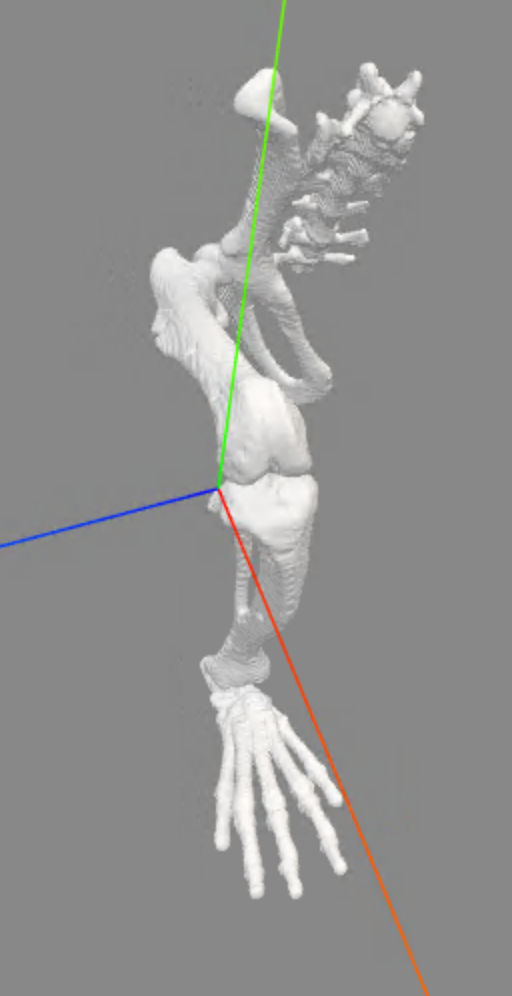

To determine the new SimmSpline, the knee was moved through its range of motion with the original configuration and the transform from the femur frame to the new tibia offset frame was recorded. The SimmSpline was then created from these values.

TODO: Replicate in code

In [ ]:
import pyopensim as osim

new_frame = [-0.00057, 0.0399598, 0.0038162]
rotation2 = [-0.087266499999999996851, -0.075049199999999996469, -0.064577200000000001268, -0.052359900000000000886, -0.040142600000000000504, -0.029670599999999998364, -0.017453300000000001452, -0.0052359900000000002621, 0.0052359900000000002621, 0.017453300000000001452, 0.029670599999999998364, 0.040142600000000000504, 0.052359900000000000886, 0.064577200000000001268]
rotation3 = [0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393, 0.26179900000000000393]
translation1 = [-0.0052385299999999999226, -0.0046464799999999997077, -0.0040425699999999996706, -0.0034725400000000000884, -0.0029796499999999999202, -0.0025907899999999999333, -0.0022994299999999998768, -0.0021100099999999998371, -0.001995639999999999914, -0.0019320699999999999246, -0.0018704800000000001026, -0.0017793500000000000722, -0.0016382700000000000474, -0.0014133999999999999862]
translation2 = [-0.034168400000000001548, -0.03425389999999999685, -0.034185599999999996546, -0.033972299999999996944, -0.033651100000000003232, -0.033278500000000002523, -0.032889799999999996816, -0.032550400000000000167, -0.032282499999999998697, -0.032116100000000001591, -0.032063200000000000034, -0.032110500000000000154, -0.032239700000000003077, -0.032414400000000002933]
translation3 = [0.0026030200000000001601, 0.0028034100000000001032, 0.0028536500000000001101, 0.002903750000000000081, 0.0028935800000000001971, 0.0027731800000000000894, 0.0027023500000000000645, 0.0026110500000000001763, 0.002469499999999999907, 0.0024171399999999999136, 0.0024041000000000001605, 0.0023809000000000000302, 0.002496410000000000122, 0.0026910400000000000119]

graph = osim.Model('models/osim/rat_hindlimb_millard_y2j.osim')
graph.initSystem()
knee: osim.CustomJoint = osim.CustomJoint.safeDownCast(graph.getJointSet().get('knee_r'))
tibia_offset: osim.PhysicalOffsetFrame = osim.PhysicalOffsetFrame.safeDownCast(knee.getChildFrame())
tibia_offset.set_translation(osim.Vec3(new_frame[0], new_frame[1], new_frame[2]))

spatial_transform: osim.SpatialTransform = knee.get_SpatialTransform()
rot2: osim.TransformAxis = spatial_transform.get_rotation2()
rot3: osim.TransformAxis = spatial_transform.get_rotation3()
rot3.set_function(osim.Constant(rotation3[0]))
trans1: osim.TransformAxis = spatial_transform.get_translation1()
simm1: osim.SimmSpline = osim.SimmSpline.safeDownCast(trans1.get_function())
for i, value in enumerate(translation1):
    simm1.setY(i, value)
trans2: osim.TransformAxis = spatial_transform.get_translation2()
simm2: osim.SimmSpline = osim.SimmSpline.safeDownCast(trans2.get_function())
for i, value in enumerate(translation2):
    simm2.setY(i, value)
trans3: osim.TransformAxis = spatial_transform.get_translation3()
simm3: osim.SimmSpline = osim.SimmSpline.safeDownCast(trans3.get_function())
for i, value in enumerate(translation3):
    simm3.setY(i, value)

graph.finalizeFromProperties()
graph.finalizeConnections()


graph.printToXML('models/osim/rat_hindlimb_millard_y2j_knee.osim')

[info] Loaded model RatHindlimbRight from file models/rat_hindlimb_millard_y2j.osim


True

## Step 5: Update the model with the new marker set
We use a different marker set than the one used in the original model, so we update the model with the new marker set.

In [ ]:
import pyopensim as osim
marker_set = osim.MarkerSet('models/osim/rat_hindlimb_unilateral_markerset.xml')

graph = osim.Model('models/osim/rat_hindlimb_millard_y2j_knee.osim')
graph.getMarkerSet().clearAndDestroy()
graph.updateMarkerSet(marker_set)
graph.printToXML('models/osim/rat_hindlimb_millard_y2j_knee_markers.osim')


[info] Loaded model RatHindlimbRight from file models/rat_hindlimb_millard_y2j_knee.osim
[info] Updated markers in model RatHindlimbRight


True

## Step 6: Update muscle parameters from Johnson 2011

In [ ]:
# Read csv file with muscle parameters
import pandas as pd
import numpy as np
import pyopensim as osim
muscle_params = pd.read_csv('data/parameters/johnson_2011_parameters.csv')
graph = osim.Model('models/osim/rat_hindlimb_millard_y2j_knee_markers.osim')
muscles : osim.SetMuscles = graph.getMuscles()
for i in range(muscles.getSize()):
    muscle : osim.Muscle = muscles.get(i)
    muscle_name = muscle.getName().replace('R_', '')
    params = muscle_params[muscle_params['Abbreviation'] == muscle_name]
    if params.empty:
        print(f"Muscle {muscle_name} not found in parameters file.")
        continue
    f0 = params['Fo (N)'].values[0]
    l0 = params['l0 (mm)'].values[0] / 1000  # Convert mm to m
    lts = params['lts (mm)'].values[0] / 1000  # Convert mm to m
    alpha = params['θ0 (deg)'].values[0] * np.pi / 180  # Convert deg to rad
    muscle.setMaxIsometricForce(f0)
    muscle.setOptimalFiberLength(l0)
    muscle.setTendonSlackLength(lts)
    muscle.setPennationAngleAtOptimalFiberLength(alpha)
    print(f"Updated {muscle_name}: F0={f0}, l0={l0}, lts={lts}, alpha={alpha}")
    
graph.printToXML('models/osim/rat_hindlimb_final.osim')

[info] Loaded model RatHindlimbRight from file models/osim/rat_hindlimb_millard_y2j_knee_markers.osim
Updated BFa: F0=3.39, l0=0.039700000000000006, lts=0.0, alpha=0.0
Updated BFp: F0=12.49, l0=0.0376, lts=0.0, alpha=0.12217304763960307
Updated CF: F0=2.06, l0=0.037899999999999996, lts=0.0, alpha=0.0
Updated STp: F0=4.54, l0=0.0436, lts=0.0, alpha=0.0
Updated STa: F0=1.39, l0=0.0341, lts=0.0, alpha=0.0
Updated SM: F0=10.22, l0=0.0357, lts=0.0, alpha=0.0
Updated QF: F0=3.0, l0=0.011, lts=0.0, alpha=0.05235987755982988
Updated TFL: F0=3.89, l0=0.0206, lts=0.0, alpha=0.19198621771937624
Updated GMa: F0=9.23, l0=0.019600000000000003, lts=0.0048, alpha=0.20943951023931953
Updated GMe: F0=18.74, l0=0.019899999999999998, lts=0.0, alpha=0.20943951023931953
Updated GMi: F0=7.39, l0=0.011800000000000001, lts=0.0, alpha=0.2792526803190927
Updated Pir: F0=11.14, l0=0.0108, lts=0.0, alpha=0.2792526803190927
Updated GP: F0=2.35, l0=0.0293, lts=0.0009, alpha=0.05235987755982988
Updated GA: F0=1.55, l

True

## Step 7: Update mass and inertia properties

In [ ]:
# TODO: Need this information

## Step 8: Update the tendon slack lengths

In [ ]:
from tsl_optimization import calc_tsl, optimize_fiber_length
from movedb.osim import OsimGraph
from pyopensim.simulation import Millard2012EquilibriumMuscle, Model
import polars as pl
import numpy as np

model = Model('models/osim/rat_hindlimb_millard_y2j_knee_markers.osim')
graph = OsimGraph(osim_model=model.clone())

results = graph.get_all_muscle_lengths_rom(min_points=100)

for muscle_name, muscle_data in results.items():
    muscle = Millard2012EquilibriumMuscle.safeDownCast(graph.get_muscle(muscle_name))
    lm_opt = muscle.getOptimalFiberLength()
    alpha_opt = muscle.getPennationAngleAtOptimalFiberLength()
    afl = muscle.getActiveForceLengthCurve()
    pfl = muscle.getFiberForceLengthCurve()
    tfl = muscle.getTendonForceLengthCurve()
    lmt = np.clip(np.sort(np.unique(muscle_data.select(pl.col(muscle_name)))), 1e-6, None)
    lm = optimize_fiber_length(lmt, lm_opt, alpha_opt, afl, pfl, tfl)
    tsl = calc_tsl(lmt, lm, lm_opt, alpha_opt, afl, pfl, tfl)
    # Update the tendon slack length in the model
    tsl_mean = np.mean(tsl)
    print(f"Muscle: {muscle_name}, New TSL: {tsl_mean}")
    graph.get_muscle(muscle_name).setTendonSlackLength(tsl_mean)
    if tsl_mean <= 0:
        print(f"Warning: Muscle {muscle_name} has non-positive TSL: {tsl_mean}. Ignoring tendon compliance")
        graph.get_muscle(muscle_name).set_ignore_tendon_compliance(True)

graph.osim_model.printToXML('models/osim/rat_hindlimb_millard_y2j_knee_markers_tsl.osim')


2025-11-19 04:48:52.630 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_pitch range: (-1.57079633, 1.57079633)
2025-11-19 04:48:52.631 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_roll range: (-1.57079633, 1.57079633)
2025-11-19 04:48:52.631 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_yaw range: (-1.57079633, 1.57079633)
2025-11-19 04:48:52.632 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_x range: (-0.1, 0.25)
2025-11-19 04:48:52.632 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_y range: (0.0, 0.2)
2025-11-19 04:48:52.633 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:136 - Coordinate sacrum_z range: (-0.1, 0.1)
2025-11-19 04:48:52.633 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:146 - Joint ground_spine connects ground and spine
2025-11-19 0

[info] Updating Model file from 40500 to latest format...
[info] Loaded model RatHindlimbRight from file models/osim/rat_hindlimb_millard_y2j_knee_markers.osim
Muscle: R_STa, New TSL: 0.0070154498452501685
Muscle: R_RF, New TSL: 0.026862819605616678
Muscle: R_BFp, New TSL: 0.005601210990650215
Muscle: R_SM, New TSL: 0.0
Muscle: R_STp, New TSL: 4.270464795976156e-05
Muscle: R_GA, New TSL: 0.004247480127329083
Muscle: R_GP, New TSL: 0.006830185075895488
Muscle: R_BFa, New TSL: 0.0056015395882346415
Muscle: R_AM, New TSL: 0.004989891708169484
Muscle: R_IP, New TSL: 0.0
Muscle: R_CF, New TSL: 0.0
Muscle: R_GMa, New TSL: 0.0
Muscle: R_Pir, New TSL: 0.0024412488187449117
Muscle: R_Pec, New TSL: 0.011072104022282049
Muscle: R_AL, New TSL: 0.0
Muscle: R_GMi, New TSL: 0.011054915439517445
Muscle: R_GS, New TSL: 0.012716346698222596
Muscle: R_TFL, New TSL: 0.007456496230063304
Muscle: R_GI, New TSL: 0.00855370454324387
Muscle: R_GMe, New TSL: 0.005265060322310507
Muscle: R_QF, New TSL: 0.0032054

True

In [1]:
import numpy as np
import scipy.io as sio
import polars as pl
# Load baseline data
group_mat_path = 'data/Control.mat'
control = sio.loadmat(group_mat_path)
baseline_right_ik = control['Timepoints']['Baseline'][0,0]['Phases'][0,0]['RightStanceSwing'][0,0]['IK'][0,0]
avg_right_ik = baseline_right_ik['Average'][0,0]*np.pi/180
std_right_ik = baseline_right_ik['StdDev'][0,0]*np.pi/180

# Problem: Currently scipy io cannot access MATLAB string arrays. Might just have to hard code it
# ik_columns = control['Info'][0,0]['IKLabels'][0].tolist()
# print(ik_columns)
ik_columns = [
    'time', 'sacrum_pitch', 'sacrum_roll', 'sacrum_yaw', 'sacrum_x', 'sacrum_y', 'sacrum_z',
    'sacroiliac_r_flx', 'hip_r_flx', 'hip_r_add', 'hip_r_int', 'knee_r_flx', 'ankle_r_flx',
    'ankle_r_add', 'ankle_r_int', 'sacroiliac_l_flx', 'hip_l_flx', 'hip_l_add', 'hip_l_int',
    'knee_l_flx', 'ankle_l_flx', 'ankle_l_add', 'ankle_l_int'
]

avg_right_ik_df = pl.DataFrame(avg_right_ik, schema=ik_columns)
std_right_ik_df = pl.DataFrame(std_right_ik, schema=ik_columns)

In [2]:
from itertools import product
from movedb.osim import OsimGraph
from pyopensim.simulation import Model
import polars as pl


model = Model('models/osim/rat_hindlimb_millard_y2j_knee_markers.osim')
graph = OsimGraph(osim_model=model.clone())
coords = ["hip_r_flx", "hip_r_add", "hip_r_int", "knee_r_flx", "ankle_r_flx"]
n_coords = len(coords)
res = 3
n_std = 1
n_combos_per_step = res**n_coords

avg_right_coords = avg_right_ik_df[coords]
std_right_coords = std_right_ik_df[coords]
n_rows = avg_right_coords.shape[0]
n_combos = n_rows*n_combos_per_step

ub = avg_right_coords + n_std*std_right_coords
lb = avg_right_coords - n_std*std_right_coords
dist = np.linspace(lb, ub, res) # 1st dimension is the resolution, 2nd dimension is the timesteps, 3rd dimension is the coords
original = dist[2, :, :]
coord_combos = np.array([list(product(*dist[:, i, :].T)) for i in range(n_rows)]).reshape(n_combos, n_coords)
coord_combos_df = pl.DataFrame(coord_combos, schema=coords)

results = {}
for coord_set, muscles in graph.coords_muscles.items():
    # If not in coords skip
    coord_set = set(coord_set).intersection(set(coords))
    if not coord_set:
        continue 
    # check for locked coordinates
    unlocked_coords = set([coord for coord in coord_set if not graph.get_coordinate(coord).getDefaultLocked()])
    if not unlocked_coords:
        continue
    state = graph.osim_model.initSystem()
    unique_combos = coord_combos_df[list(unlocked_coords)].unique()
    n_unique_combos = len(unique_combos)

    data = np.zeros((n_unique_combos, len(unlocked_coords) + len(muscles)))
    data[:, :len(unlocked_coords)] = unique_combos.to_numpy()
    for i in range(n_unique_combos):
        for coord in unlocked_coords:
            value = unique_combos[i][coord].item()
            graph.get_coordinate(coord).setValue(state, value)
        graph.osim_model.realizePosition(state)
        muscle_lengths = graph.get_muscle_lengths(list(muscles), state)
        data[i, len(unlocked_coords):] = muscle_lengths
    df = pl.DataFrame(data, schema=list(unlocked_coords) + list(muscles))
    results.update({muscle: df[list(unlocked_coords) + [muscle]] for muscle in muscles})

2025-11-19 09:50:52.471 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_pitch range: (-1.57079633, 1.57079633)
2025-11-19 09:50:52.472 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_roll range: (-1.57079633, 1.57079633)
2025-11-19 09:50:52.472 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_yaw range: (-1.57079633, 1.57079633)
2025-11-19 09:50:52.472 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_x range: (-0.1, 0.25)
2025-11-19 09:50:52.473 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_y range: (0.0, 0.2)
2025-11-19 09:50:52.473 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:137 - Coordinate sacrum_z range: (-0.1, 0.1)
2025-11-19 09:50:52.473 | DEBUG    | movedb.osim.analysis.osim_graph:create_rigid_graph:147 - Joint ground_spine connects ground and spine
2025-11-19 0

[info] Updating Model file from 40500 to latest format...
[info] Loaded model RatHindlimbRight from file models/osim/rat_hindlimb_millard_y2j_knee_markers.osim


In [3]:
from tsl_optimization import calc_tsl, optimize_fiber_length
from pyopensim.simulation import Millard2012EquilibriumMuscle
import polars as pl
import numpy as np
for muscle_name, muscle_data in results.items():
    muscle = Millard2012EquilibriumMuscle.safeDownCast(graph.get_muscle(muscle_name))
    lm_opt = muscle.getOptimalFiberLength()
    alpha_opt = muscle.getPennationAngleAtOptimalFiberLength()
    afl = muscle.getActiveForceLengthCurve()
    pfl = muscle.getFiberForceLengthCurve()
    tfl = muscle.getTendonForceLengthCurve()
    lmt = np.clip(np.sort(np.unique(muscle_data.select(pl.col(muscle_name)))), 1e-6, None)
    lm = optimize_fiber_length(lmt, lm_opt, alpha_opt, afl, pfl, tfl)
    tsl = calc_tsl(lmt, lm, lm_opt, alpha_opt, afl, pfl, tfl)
    # Update the tendon slack length in the model
    tsl_mean = np.mean(tsl)
    print(f"Muscle: {muscle_name}, New TSL: {tsl_mean}")
    graph.get_muscle(muscle_name).setTendonSlackLength(tsl_mean)
    if tsl_mean <= 0:
        print(f"Warning: Muscle {muscle_name} has non-positive TSL: {tsl_mean}. Ignoring tendon compliance")
        graph.get_muscle(muscle_name).set_ignore_tendon_compliance(True)

graph.osim_model.printToXML('models/osim/rat_hindlimb_millard_y2j_knee_markers_tsl2.osim')


KeyboardInterrupt: 

## Final Step: Create Bilateral Model
To mirror the right side of the model to the left, a series of steps needs to happen:
- Duplicate bodies
    - Follow the naming convention of `{body}_l` and `{body}_r`
    - For the left side, the attached_geometry will be the same as the right side, but the scale_factors will be 1 1 -1
    - The mass and inertia properties will need to be updated to reflect the new bodies
- Duplicate joints 
    - Follow the naming convention of `{joint}_l` and `{joint}_r`
    - Frames that reference bodies will need to be updated to reference the new bodies
    - Physical offset frames with Z translations will need to be negated
    - Spatial transforms with Z translations will need to be negated
- Duplicate muscles
    - Follow the naming convention of `L_{muscle}` and `R_{muscle}`
    - Path points will need to be updated to reference the new bodies
    - For the left side Z translations will need to be negated
- Duplicate markers 
    - Follow the naming convention of `L{marker}` and `R{marker}`
    - Markers will need to be updated to reference the new bodies
    - For the left side Z translations will need to be negated

In [ ]:
from pyopensim.simulation import (
    BodySet, 
    Body,
    Geometry,
    Joint,
    JointSet,
    PhysicalOffsetFrame,
    CustomJoint,
    SpatialTransform,
    TransformAxis,
    Muscle,
    ForceSet,
    PathPoint,
    PathPointSet,
    MarkerSet,
    Model,
)
from pyopensim.common import (
    Function,
    LinearFunction,
    Constant,
    MultiplierFunction,
    SimmSpline,
)
from pyopensim.simbody import Inertia, Vec3
graph = Model('models/osim/rat_hindlimb_millard_y2j_knee_markers_tsl.osim')

# Don't duplicate spine, but duplicate the rest
body_set: BodySet = graph.getBodySet()
cloned_bodies = {}
n_bodies = body_set.getSize()
for i in range(n_bodies):
    body: Body = graph.getBodySet().get(i)
    body_name: str = body.getName()
    new_body_name = body_name
    if body_name != 'spine':
        new_body: Body = body.clone()
        new_body_name = body_name.replace('_r', '_l')
        new_body.setName(new_body_name)
        geom: Geometry = new_body.get_attached_geometry(0)
        geom.setName(geom.getName().replace('_r', '_l'))
        geom.set_scale_factors(Vec3(1, 1, -1))
        com: Vec3 = new_body.getMassCenter()
        new_body.setMassCenter(Vec3([com.get(0), com.get(1), -com.get(2)]))
        moi: Inertia = new_body.getInertia()
        moments: Vec3 = moi.getMoments()
        products: Vec3 = moi.getProducts()
        new_body.setInertia(Inertia(
                            moments.get(0), moments.get(1), moments.get(2),
                            products.get(0), -products.get(1), -products.get(2)))
        graph.addBody(new_body)
    cloned_bodies[body_name] = new_body_name

joint_set: JointSet = graph.getJointSet()
left_joint_set: JointSet = joint_set.clone()
# Remove ground_spine
left_joint_set.remove(left_joint_set.get('ground_spine'))

left_joint_set_file = 'models/osim/left_joint_set.xml'
left_joint_set.printToXML(left_joint_set_file)
with open(left_joint_set_file, 'r') as file:
    joint_set_content = file.read()

for old_body_name, new_body_name in cloned_bodies.items():
    joint_set_content = joint_set_content.replace(old_body_name, new_body_name)

new_joint_names = []
for i in range(left_joint_set.getSize()):
    joint: Joint = left_joint_set.get(i)
    joint_name: str = joint.getName()
    new_joint_name: str = joint_name.replace('_r', '_l')
    joint_set_content = joint_set_content.replace(joint_name, new_joint_name)
    new_joint_names.append(new_joint_name)
    
with open(left_joint_set_file, 'w') as file:
    file.write(joint_set_content)
    
left_joint_set = JointSet(left_joint_set_file)
# Remove the left_joint_set file
import os
os.remove(left_joint_set_file)
    
js: JointSet = graph.getJointSet()service that lets people rent time on your 3d printer
for i in range(left_joint_set.getSize()):
    js.cloneAndAppend(left_joint_set.get(i))

graph.initSystem()
for joint_name in new_joint_names:
    joint: CustomJoint = CustomJoint.safeDownCast(graph.getJointSet().get(joint_name))
    if joint is None:
        print(f"Joint {joint_name} not found in the model.")
        continue
    # Mirror the parent and child frames
    parent_offset: PhysicalOffsetFrame = PhysicalOffsetFrame.safeDownCast(joint.getParentFrame())
    parent_pos = parent_offset.get_translation()
    parent_rot = parent_offset.get_orientation()
    child_offset: PhysicalOffsetFrame = PhysicalOffsetFrame.safeDownCast(joint.getChildFrame())
    child_pos = child_offset.get_translation()
    child_rot = child_offset.get_orientation()
    parent_offset.set_translation(Vec3(parent_pos.get(0), parent_pos.get(1), -parent_pos.get(2)))
    child_offset.set_translation(Vec3(child_pos.get(0), child_pos.get(1), -child_pos.get(2)))
    
    # Mirror the spatial transform
    spatial_transform: SpatialTransform = joint.get_SpatialTransform()
    transform_axes: list[Vec3] = spatial_transform.getAxes()
    for i, vec in enumerate(transform_axes):
        # For rotations, negate x and y components
        # For translations, negate z component
        if i <= 2 and vec[2]:  # Skip the first three axes (rotation1-3)
            continue
        elif i > 2 and not vec[2]:  # Skip the first three axes (translation1-3)
            continue
            
        # Assume that order is always rotation1-3, translation1-3
        get_transform_function = ('get_rotation' + str(i+1)) if i < 3 else ('get_translation' + str(i-2))
        transform_axis: TransformAxis = getattr(spatial_transform, get_transform_function)()
        axis_function: Function = transform_axis.getFunction()
        concreteClass = axis_function.getConcreteClassName()
        match concreteClass:
            case 'SimmSpline':
                # Mirror the function
                simm_spline: SimmSpline = SimmSpline.safeDownCast(axis_function)
                if simm_spline is None:
                    raise ValueError("Function is not a SimmSpline.")
                for k in range(simm_spline.getSize()):
                    y: float = simm_spline.getY(k)
                    simm_spline.setY(k, -y)
            case 'LinearFunction':
                linear_func: LinearFunction = LinearFunction.safeDownCast(axis_function)
                if linear_func is None:
                    raise ValueError("Function is not a LinearFunction.")
                linear_func.setSlope(-linear_func.getSlope())
                linear_func.setIntercept(-linear_func.getIntercept())
            case 'Constant':
                constant_func: Constant = Constant.safeDownCast(axis_function)
                if constant_func is None:
                    raise ValueError("Function is not a Constant.")
                constant_func.setValue(-constant_func.getValue())
            case 'MultiplierFunction':
                mult_func: MultiplierFunction = MultiplierFunction.safeDownCast(axis_function)
                if mult_func is None:
                    raise ValueError("Function is not a MultiplierFunction.")
                # For MultiplierFunction, negate the scale
                mult_func.setScale(-mult_func.getScale())
            case _:
                print(f"Unsupported function type: {concreteClass}, not mirroring")

# Update muscles 
muscle_set: ForceSet = graph.getForceSet()
left_muscle_set_file = 'models/osim/left_muscle_set.xml'
muscle_set.printToXML(left_muscle_set_file)
with open(left_muscle_set_file, 'r') as file:
    muscle_set_content = file.read()

for old_body_name, new_body_name in cloned_bodies.items():
    muscle_set_content = muscle_set_content.replace(old_body_name, new_body_name)
    
new_muscle_names = []
for i in range(muscle_set.getSize()):
    muscle: Muscle = muscle_set.get(i)
    muscle_name: str = muscle.getName()
    new_muscle_name: str = muscle_name.replace('R_', 'L_')
    muscle_set_content = muscle_set_content.replace(muscle_name, new_muscle_name)
    new_muscle_names.append(new_muscle_name)

for old_body_name, new_body_name in cloned_bodies.items():
    muscle_set_content = muscle_set_content.replace(old_body_name, new_body_name)

with open(left_muscle_set_file, 'w') as file:
    file.write(muscle_set_content)
    
left_muscle_set = ForceSet(left_muscle_set_file)
os.remove(left_muscle_set_file)

for muscle_name in new_muscle_names:
    muscle: Muscle = Muscle.safeDownCast(left_muscle_set.get(muscle_name))
    path_points: PathPointSet = muscle.getGeometryPath().getPathPointSet()
    for i in range(path_points.getSize()):
        path_point: PathPoint = PathPoint.safeDownCast(path_points.get(i))
        loc: Vec3 = path_point.get_location()
        path_point.setLocation(Vec3(loc.get(0), loc.get(1), -loc.get(2)))
    muscle_set.append(muscle)

# Make sure to update the model before printing
graph.finalizeFromProperties()
graph.finalizeConnections()

# For some reason this has to happen after finalizing connections
marker_set = MarkerSet('models/osim/rat_hindlimb_bilateral_markerset.xml')
graph.getMarkerSet().clearAndDestroy()
graph.updateMarkerSet(marker_set)
graph.setName("RatHindlimb")

graph.printToXML('models/osim/rat_hindlimb_bilateral.osim')

[info] Loaded model RatHindlimbRight from file models/osim/rat_hindlimb_millard_y2j_knee_markers_tsl.osim
[info] Updated markers in model RatHindlimbRight


True